In [1]:
import pandas as pd
import os

# 데이터 경로
data_path = os.getenv("HOME") + '/work/sentiment_classification/data/'

# 네이버 영화리뷰 읽기 (탭으로 구분된 파일)
train_data = pd.read_table(data_path + 'ratings_train.txt')
test_data = pd.read_table(data_path + 'ratings_test.txt')

print("train 크기:", len(train_data))
print("test 크기:", len(test_data))
train_data.head()

train 크기: 150000
test 크기: 50000


,id,document,label
0,9976970,아 더빙.. 진짜 짜증나네요 목소리,0
1,3819312,흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나,1
2,10265843,너무재밓었다그래서보는것을추천한다,0
3,9045019,교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정,0
4,6483659,사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 ...,1


In [2]:
from konlpy.tag import Mecab

tokenizer = Mecab()
print(tokenizer.morphs("아 더빙 진짜 짜증나네요"))

['아', '더', '빙', '진짜', '짜증', '나', '네요']


In [3]:
!pip install konlpy

In [4]:
!bash <(curl -s https://raw.githubusercontent.com/konlpy/konlpy/master/scripts/mecab.sh)

mecab-ko is already installed
mecab-ko-dic is already installed
<string>:1: DeprecationWarning: 'pkgutil.find_loader' is deprecated and slated for removal in Python 3.14; use importlib.util.find_spec() instead
mecab-python is already installed
Done.


하...

In [5]:
!pip install mecab-python3
!pip install mecab-ko-dic

In [6]:
import MeCab

tagger = MeCab.Tagger()
print(tagger.parse("아 더빙 진짜 짜증나네요"))

아	IC,*,F,아,Inflect,IC,IC,아이/IC/*
더	MAG,성분부사|정도부사,F,더,*,*,*,*
빙	MAG,성분부사|양태부사,T,빙,*,*,*,*
진짜	MAG,문장부사|양상부사,F,진짜,*,*,*,*
짜증	NNG,행위,T,짜증,*,*,*,*
나	NP,*,F,나,*,*,*,*
네요	VCP+EC,*,F,네요,Inflect,VCP,EC,이/VCP/*+네요/EC/*
EOS



In [7]:
import MeCab

mecab = MeCab.Tagger()

def mecab_morphs(text):
    # 형태소만 추출 (품사 정보 제거)
    parsed = mecab.parse(text)
    morphs = []
    for line in parsed.split('\n'):
        if line == 'EOS' or line == '':
            continue
        word = line.split('\t')[0]  # 탭 앞부분이 형태소
        morphs.append(word)
    return morphs

# 테스트
print(mecab_morphs("아 더빙 진짜 짜증나네요"))

['아', '더', '빙', '진짜', '짜증', '나', '네요']


토크나이저 준비완료

In [8]:
import numpy as np
from collections import Counter

# 불용어 (의미 없는 조사·어미 등)
stopwords = ['의','가','이','은','들','는','좀','잘','걍','과','도','를','으로','자','에','와','한','하다']

def load_data(train_data, test_data, num_words=10000):
    # 1. 중복·결측 제거
    train_data.drop_duplicates(subset=['document'], inplace=True)
    train_data = train_data.dropna(how='any')
    test_data.drop_duplicates(subset=['document'], inplace=True)
    test_data = test_data.dropna(how='any')

    # 2. 토큰화 + 불용어 제거
    X_train = []
    for sentence in train_data['document']:
        temp = mecab_morphs(sentence)
        temp = [word for word in temp if word not in stopwords]
        X_train.append(temp)

    X_test = []
    for sentence in test_data['document']:
        temp = mecab_morphs(sentence)
        temp = [word for word in temp if word not in stopwords]
        X_test.append(temp)

    # 3. 단어사전 구성 (자주 나온 단어 num_words개)
    words = np.concatenate(X_train).tolist()
    counter = Counter(words)
    counter = counter.most_common(num_words - 4)
    vocab = ['', '', '', ''] + [key for key, _ in counter]
    word_to_index = {word: index for index, word in enumerate(vocab)}

    # 4. 텍스트를 숫자 인덱스로 변환
    def wordlist_to_indexlist(wordlist):
        return [word_to_index[word] if word in word_to_index else 3 for word in wordlist]

    X_train = list(map(wordlist_to_indexlist, X_train))
    X_test = list(map(wordlist_to_indexlist, X_test))

    return X_train, np.array(list(train_data['label'])), X_test, np.array(list(test_data['label'])), word_to_index

X_train, y_train, X_test, y_test, word_to_index = load_data(train_data, test_data)
print("완료 — 단어사전 크기:", len(word_to_index))

완료 — 단어사전 크기: 9997


In [9]:
# 첫 번째 리뷰가 숫자로 어떻게 바뀌었나
print("숫자로 변환된 첫 리뷰:", X_train[0])
print("라벨:", y_train[0])
print("단어사전 크기:", len(word_to_index))
print("학습 데이터 수:", len(X_train))

숫자로 변환된 첫 리뷰: [32, 74, 939, 4, 4, 39, 229, 20, 33, 747]
라벨: 0
단어사전 크기: 9997
학습 데이터 수: 146182


최대 길이: 116
평균 길이: 15.983137458784256


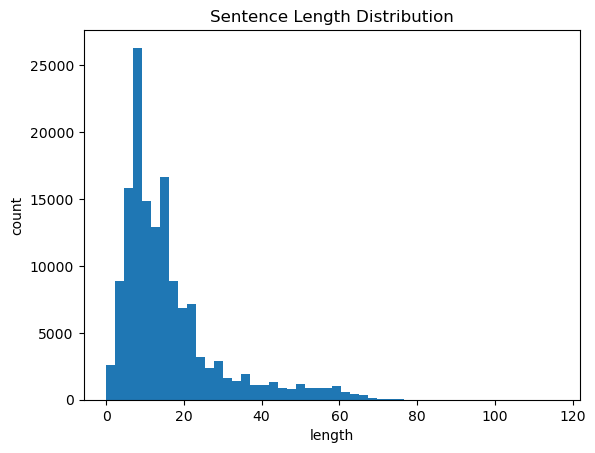

In [10]:
import matplotlib.pyplot as plt

# 각 문장의 길이 계산
lengths = [len(x) for x in X_train]

print("최대 길이:", max(lengths))
print("평균 길이:", sum(lengths) / len(lengths))

plt.hist(lengths, bins=50)
plt.xlabel('length')
plt.ylabel('count')
plt.title('Sentence Length Distribution')
plt.show()

In [12]:
import torch
from torch.nn.utils.rnn import pad_sequence

max_len = 40

def pad_data(X, max_len):
    result = []
    for seq in X:
        if len(seq) < max_len:
            # pre 패딩: 앞쪽을 0으로 채움 (RNN은 끝부분이 중요)
            seq = [0] * (max_len - len(seq)) + seq
        else:
            seq = seq[:max_len]  # 길면 자름
        result.append(seq)
    return torch.tensor(result)

X_train_pad = pad_data(X_train, max_len)
X_test_pad = pad_data(X_test, max_len)
X_train_pad = torch.clamp(X_train_pad, max=9996)  #오류로 추가
X_test_pad = torch.clamp(X_test_pad, max=9996)   

print("패딩 후 shape:", X_train_pad.shape)
print("첫 리뷰:", X_train_pad[0])

패딩 후 shape: torch.Size([146182, 40])
첫 리뷰: tensor([  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,  32,  74, 939,   4,   4,  39, 229,  20,  33, 747])


In [13]:
from torch.utils.data import TensorDataset, DataLoader

# 학습 데이터의 일부를 검증용으로 분리 (앞 3만개)
X_val = X_train_pad[:30000]
y_val = torch.tensor(y_train[:30000])
X_tr = X_train_pad[30000:]
y_tr = torch.tensor(y_train[30000:])

# 텐서로 묶어 DataLoader 구성
train_ds = TensorDataset(X_tr, y_tr)
val_ds = TensorDataset(X_val, y_val)
test_ds = TensorDataset(X_test_pad, torch.tensor(y_test))

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)

print("train:", len(train_ds), "/ val:", len(val_ds), "/ test:", len(test_ds))

train: 116182 / val: 30000 / test: 49157


In [14]:
import torch.nn as nn

class SimpleRNN(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=128, num_classes=2):
        super().__init__()
        # 단어 인덱스 → 벡터로 변환
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        # 기본 RNN (순서대로 state 누적)
        self.rnn = nn.RNN(embed_dim, hidden_dim, batch_first=True)
        # 마지막 state → 긍/부정 분류
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        x = self.embedding(x)           # (배치, 길이) → (배치, 길이, embed_dim)
        output, hidden = self.rnn(x)    # hidden = 마지막 state
        out = self.fc(hidden.squeeze(0))  # 마지막 state로 분류
        return out

vocab_size = 10000   # len(word_to_index) 에서 10000으로 수정
rnn_model = SimpleRNN(vocab_size)
print(rnn_model)

SimpleRNN(
  (embedding): Embedding(10000, 128, padding_idx=0)
  (rnn): RNN(128, 128, batch_first=True)
  (fc): Linear(in_features=128, out_features=2, bias=True)
)


In [15]:
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def train_model(model, train_loader, val_loader, epochs=5, name="model"):
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    history = {'train_loss': [], 'val_acc': []}

    for epoch in range(epochs):
        # 학습
        model.train()
        total_loss = 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        train_loss = total_loss / len(train_loader)

        # 검증
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                out = model(x)
                _, pred = out.max(1)
                total += y.size(0)
                correct += pred.eq(y).sum().item()
        val_acc = 100. * correct / total

        history['train_loss'].append(train_loss)
        history['val_acc'].append(val_acc)
        print(f"[{name}] Epoch {epoch+1}/{epochs} | loss: {train_loss:.4f} | val_acc: {val_acc:.2f}%")

    return history

In [16]:
print("=== 기본 RNN 학습 ===")
history_rnn = train_model(rnn_model, train_loader, val_loader, epochs=5, name="RNN")

=== 기본 RNN 학습 ===
[RNN] Epoch 1/5 | loss: 0.5048 | val_acc: 79.47%
[RNN] Epoch 2/5 | loss: 0.4019 | val_acc: 82.37%
[RNN] Epoch 3/5 | loss: 0.3562 | val_acc: 84.41%
[RNN] Epoch 4/5 | loss: 0.3303 | val_acc: 83.26%
[RNN] Epoch 5/5 | loss: 0.3114 | val_acc: 84.79%


In [17]:
print("사전 크기:", len(word_to_index))
print("X_train 최대 인덱스:", X_train_pad.max().item())
print("X_test 최대 인덱스:", X_test_pad.max().item())

사전 크기: 9997
X_train 최대 인덱스: 9996
X_test 최대 인덱스: 9996


하아... 임베딩크기 조정
vocab_size = len(word_to_index) 를 vocab_size = 10000로

X_train_pad = torch.clamp(X_train_pad, max=9996)
X_test_pad = torch.clamp(X_test_pad, max=9996) 추가

In [18]:
class LSTMModel(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=128, num_classes=2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)  # RNN→LSTM
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        x = self.embedding(x)
        output, (hidden, cell) = self.lstm(x)  # LSTM은 hidden + cell 둘 반환
        out = self.fc(hidden.squeeze(0))
        return out

lstm_model = LSTMModel(vocab_size)
print("=== LSTM 학습 ===")
history_lstm = train_model(lstm_model, train_loader, val_loader, epochs=5, name="LSTM")

=== LSTM 학습 ===
[LSTM] Epoch 1/5 | loss: 0.4203 | val_acc: 84.50%
[LSTM] Epoch 2/5 | loss: 0.3108 | val_acc: 86.18%
[LSTM] Epoch 3/5 | loss: 0.2609 | val_acc: 86.19%
[LSTM] Epoch 4/5 | loss: 0.2147 | val_acc: 85.96%
[LSTM] Epoch 5/5 | loss: 0.1659 | val_acc: 85.88%


Epoch 3이후 val 감소(살짝 과적합 보임, RNN보다는 나음)

In [19]:
class CNNModel(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, num_filters=128, num_classes=2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        # 1D 합성곱: 연속된 단어 묶음의 패턴 포착 (kernel_size=3 → 3단어씩)
        self.conv = nn.Conv1d(embed_dim, num_filters, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.fc = nn.Linear(num_filters, num_classes)

    def forward(self, x):
        x = self.embedding(x)        # (배치, 길이, embed_dim)
        x = x.permute(0, 2, 1)       # Conv1d용으로 축 변경 (배치, embed_dim, 길이)
        x = self.relu(self.conv(x))  # 합성곱 + 활성화
        x = torch.max(x, dim=2)[0]   # GlobalMaxPool: 가장 강한 특징만 추출
        out = self.fc(x)
        return out

cnn_model = CNNModel(vocab_size)
print("=== 1D CNN 학습 ===")
history_cnn = train_model(cnn_model, train_loader, val_loader, epochs=5, name="CNN")

=== 1D CNN 학습 ===
[CNN] Epoch 1/5 | loss: 0.4203 | val_acc: 83.01%
[CNN] Epoch 2/5 | loss: 0.3126 | val_acc: 84.73%
[CNN] Epoch 3/5 | loss: 0.2495 | val_acc: 84.93%
[CNN] Epoch 4/5 | loss: 0.1918 | val_acc: 84.71%
[CNN] Epoch 5/5 | loss: 0.1424 | val_acc: 84.36%


마찬가지로 Epoch 3이후 val 감소(살짝 과적합 보임)

In [20]:
class SimpleModel(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, num_classes=2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.fc = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        x = self.embedding(x)        # (배치, 길이, embed_dim)
        x = torch.mean(x, dim=1)     # 단어 벡터들의 평균 (문장 전체를 한 벡터로)
        out = self.fc(x)
        return out

simple_model = SimpleModel(vocab_size)
print("=== 간단 모델 학습 ===")
history_simple = train_model(simple_model, train_loader, val_loader, epochs=5, name="Simple")

=== 간단 모델 학습 ===
[Simple] Epoch 1/5 | loss: 0.4776 | val_acc: 83.58%
[Simple] Epoch 2/5 | loss: 0.3686 | val_acc: 84.42%
[Simple] Epoch 3/5 | loss: 0.3462 | val_acc: 84.70%
[Simple] Epoch 4/5 | loss: 0.3345 | val_acc: 84.74%
[Simple] Epoch 5/5 | loss: 0.3268 | val_acc: 84.65%


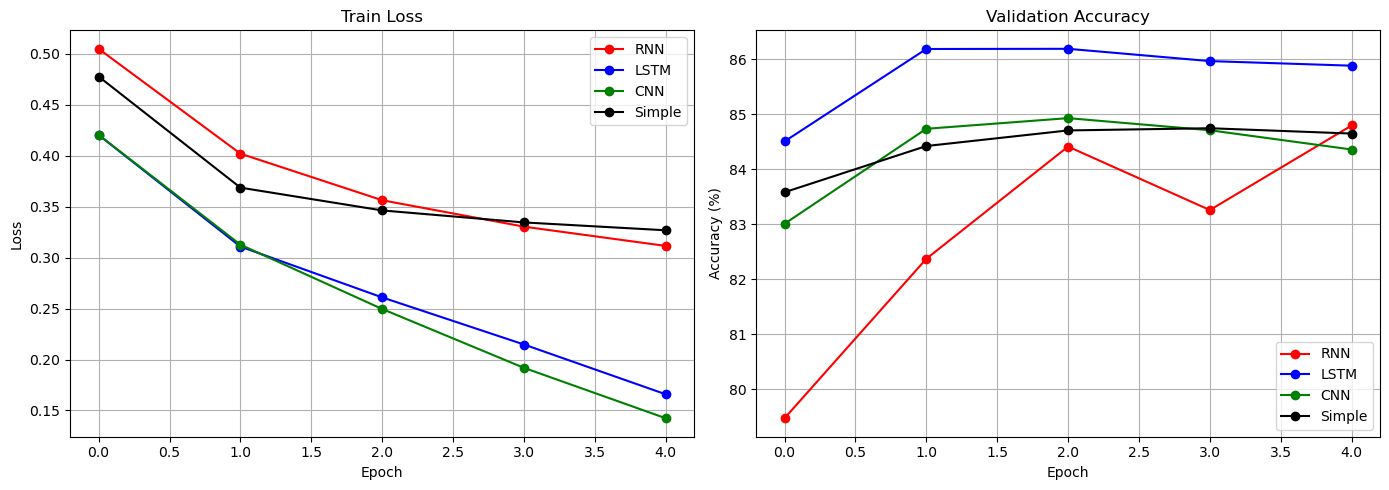

In [21]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss
ax1.plot(history_rnn['train_loss'], 'r-o', label='RNN')
ax1.plot(history_lstm['train_loss'], 'b-o', label='LSTM')
ax1.plot(history_cnn['train_loss'], 'g-o', label='CNN')
ax1.plot(history_simple['train_loss'], 'k-o', label='Simple')
ax1.set_title('Train Loss')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.legend(); ax1.grid(True)

# Accuracy
ax2.plot(history_rnn['val_acc'], 'r-o', label='RNN')
ax2.plot(history_lstm['val_acc'], 'b-o', label='LSTM')
ax2.plot(history_cnn['val_acc'], 'g-o', label='CNN')
ax2.plot(history_simple['val_acc'], 'k-o', label='Simple')
ax2.set_title('Validation Accuracy')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)')
ax2.legend(); ax2.grid(True)

plt.tight_layout()
plt.show()

순서보단 어떤 한 단어(최악, 재미없다) 등이 결정적으로 더 중요할 가능성 제시
LSTM의 문맥을 잡는 능력이 더 나은 결과를 보여줌

In [23]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 47.6 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [gensim]2m2/3 [gensim]


In [24]:
from gensim.models import Word2Vec

word2vec_path = data_path + 'word2vec_ko.model'
w2v = Word2Vec.load(word2vec_path)

print("Word2Vec 단어 수:", len(w2v.wv))
print("벡터 차원:", w2v.wv.vector_size)

print("\n'영화'와 비슷한 단어:")
for word, score in w2v.wv.most_similar('영화', topn=5):
    print(f"  {word}: {score:.3f}")

Word2Vec 단어 수: 302960
벡터 차원: 100

'영화'와 비슷한 단어:
  드라마: 0.842
  뮤지컬: 0.778
  코미디: 0.749
  다큐멘터리: 0.740
  헐리우드: 0.740


In [25]:
import numpy as np

embed_dim = 100  # Word2Vec 차원에 맞춤

# 우리 사전 크기만큼 임베딩 행렬 준비 (0으로 초기화)
embedding_matrix = np.zeros((vocab_size, embed_dim))

# 우리 사전의 각 단어에 Word2Vec 벡터 채우기
found = 0
for word, idx in word_to_index.items():
    if word in w2v.wv:
        embedding_matrix[idx] = w2v.wv[word]
        found += 1

print(f"전체 {len(word_to_index)}개 중 {found}개 단어를 Word2Vec에서 찾음")

전체 9997개 중 9457개 단어를 Word2Vec에서 찾음


In [26]:
class LSTMWord2Vec(nn.Module):
    def __init__(self, embedding_matrix, hidden_dim=128, num_classes=2):
        super().__init__()
        vocab_size, embed_dim = embedding_matrix.shape
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        # Word2Vec 벡터를 임베딩 초기값으로 주입
        self.embedding.weight.data.copy_(torch.tensor(embedding_matrix, dtype=torch.float))
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        x = self.embedding(x)
        output, (hidden, cell) = self.lstm(x)
        out = self.fc(hidden.squeeze(0))
        return out

lstm_w2v = LSTMWord2Vec(embedding_matrix)
print("=== LSTM + Word2Vec 학습 ===")
history_w2v = train_model(lstm_w2v, train_loader, val_loader, epochs=5, name="LSTM+W2V")

=== LSTM + Word2Vec 학습 ===
[LSTM+W2V] Epoch 1/5 | loss: 0.4032 | val_acc: 85.51%
[LSTM+W2V] Epoch 2/5 | loss: 0.3032 | val_acc: 86.48%
[LSTM+W2V] Epoch 3/5 | loss: 0.2623 | val_acc: 86.57%
[LSTM+W2V] Epoch 4/5 | loss: 0.2284 | val_acc: 86.74%
[LSTM+W2V] Epoch 5/5 | loss: 0.1944 | val_acc: 86.38%


In [28]:
class LSTM2Layer(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=128, num_classes=2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        # LSTM 2층 쌓기 (num_layers=2), 과적합 방지용 dropout
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers=2,
                            batch_first=True, dropout=0.3)
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        x = self.embedding(x)
        output, (hidden, cell) = self.lstm(x)
        # 2층이면 hidden이 [2, 배치, hidden_dim] → 마지막 층([-1]) 사용
        out = self.fc(hidden[-1])
        return out

lstm2_model = LSTM2Layer(vocab_size)
print("=== 2-Layer LSTM 학습 ===")
history_lstm2 = train_model(lstm2_model, train_loader, val_loader, epochs=5, name="LSTM-2L")

=== 2-Layer LSTM 학습 ===
[LSTM-2L] Epoch 1/5 | loss: 0.4175 | val_acc: 84.64%
[LSTM-2L] Epoch 2/5 | loss: 0.3131 | val_acc: 86.08%
[LSTM-2L] Epoch 3/5 | loss: 0.2637 | val_acc: 86.35%
[LSTM-2L] Epoch 4/5 | loss: 0.2196 | val_acc: 86.41%
[LSTM-2L] Epoch 5/5 | loss: 0.1792 | val_acc: 86.46%


1층 LSTM보다 살짝 높지만 Word2Vec보단 낮은 모습

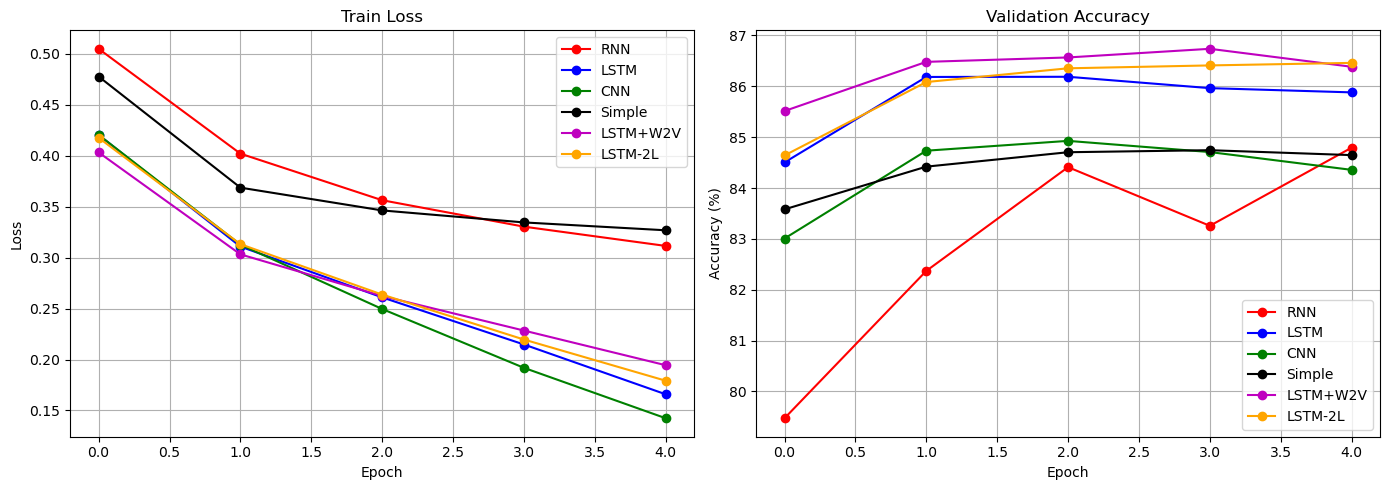

In [29]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Train Loss
ax1.plot(history_rnn['train_loss'], 'r-o', label='RNN')
ax1.plot(history_lstm['train_loss'], 'b-o', label='LSTM')
ax1.plot(history_cnn['train_loss'], 'g-o', label='CNN')
ax1.plot(history_simple['train_loss'], 'k-o', label='Simple')
ax1.plot(history_w2v['train_loss'], 'm-o', label='LSTM+W2V')
ax1.plot(history_lstm2['train_loss'], color='orange', marker='o', label='LSTM-2L')
ax1.set_title('Train Loss')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.legend(); ax1.grid(True)

# Validation Accuracy
ax2.plot(history_rnn['val_acc'], 'r-o', label='RNN')
ax2.plot(history_lstm['val_acc'], 'b-o', label='LSTM')
ax2.plot(history_cnn['val_acc'], 'g-o', label='CNN')
ax2.plot(history_simple['val_acc'], 'k-o', label='Simple')
ax2.plot(history_w2v['val_acc'], 'm-o', label='LSTM+W2V')
ax2.plot(history_lstm2['val_acc'], color='orange', marker='o', label='LSTM-2L')
ax2.set_title('Validation Accuracy')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)')
ax2.legend(); ax2.grid(True)

plt.tight_layout()
plt.show()

보라(W2V)와 빨강(RNN)의 epoch0 출발점 차이 — 85.5% vs 79.5%
같은 LSTM이라도 임베딩을 Word2Vec으로 시작하면 처음부터 앞섬(전이학습의 효과가 시각적으로 명확)
1층 LSTM과 2층 LSTM은 거의 겹침(모델의 깊이보단 단어표현의 질을 올린 Word2Vec 임베딩이 더 중요)